In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("paysim.csv")

In [3]:
print("Shape:",df.shape)
print("\nColumn types:\n",df.dtypes)
print("\nMissing values:\n",df.isnull().sum())
print("\nFraud count:\n",df['isFraud'].value_counts())
print("\nFraud %:\n",df['isFraud'].value_counts(normalize=True)*100)

Shape: (6362620, 11)

Column types:
 step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Missing values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Fraud count:
 isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud %:
 isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


In [4]:
print(df['isFlaggedFraud'].value_counts())
print(pd.crosstab(df['isFraud'], df['isFlaggedFraud']))

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64
isFlaggedFraud        0   1
isFraud                    
0               6354407   0
1                  8197  16


In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df['nameOrig_prefix'] = df['nameOrig'].str[0]
df['nameDest_prefix'] = df['nameDest'].str[0]

print(df['nameOrig_prefix'].value_counts())
print(pd.crosstab(df['nameDest_prefix'],df['type']))

nameOrig_prefix
C    6362620
Name: count, dtype: int64
type             CASH_IN  CASH_OUT  DEBIT  PAYMENT  TRANSFER
nameDest_prefix                                             
C                1399284   2237500  41432        0    532909
M                      0         0      0  2151495         0


In [7]:
merchant_dest = df[df['nameDest_prefix'] == 'M']
print(merchant_dest[['oldbalanceDest', 'newbalanceDest']].describe())

       oldbalanceDest  newbalanceDest
count       2151495.0       2151495.0
mean              0.0             0.0
std               0.0             0.0
min               0.0             0.0
25%               0.0             0.0
50%               0.0             0.0
75%               0.0             0.0
max               0.0             0.0


In [8]:
df = df[df['type'].isin(['CASH_OUT', 'TRANSFER'])].copy()
df = df.drop(columns=['nameOrig_prefix', 'nameDest_prefix'])

print("New shape:", df.shape)
print(df['isFraud'].value_counts())
print(df['isFraud'].value_counts(normalize=True) * 100)

New shape: (2770409, 11)
isFraud
0    2762196
1       8213
Name: count, dtype: int64
isFraud
0    99.703546
1     0.296454
Name: proportion, dtype: float64


In [9]:
df['orig_balance_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']
df['dest_balance_diff'] = df['newbalanceDest'] - df['oldbalanceDest'] - df['amount']

In [10]:
print(df[['orig_balance_diff', 'dest_balance_diff']].describe())
print(df.groupby('isFraud')[['orig_balance_diff', 'dest_balance_diff']].mean())

       orig_balance_diff  dest_balance_diff
count       2.770409e+06       2.770409e+06
mean       -2.859850e+05       2.864713e+04
std         8.753230e+05       5.934794e+05
min        -9.244552e+07      -1.000000e+07
25%        -2.798912e+05      -5.820766e-11
50%        -1.435971e+05       0.000000e+00
75%        -5.185310e+04       7.275958e-11
max         1.000000e-02       7.588573e+07
         orig_balance_diff  dest_balance_diff
isFraud                                      
0           -286803.509954       30910.325352
1            -10692.325265     -732509.301069


In [11]:
zero_balance_check = ((df['oldbalanceOrg']==0) & (df['newbalanceOrig']==0) & (df['amount']>0))
print("Rows with zero orig balance but nonzero amount : ", zero_balance_check.sum())
print("Out of total :",len(df))
print(df.groupby('isFraud').apply(lambda x: ((x['oldbalanceOrg'] == 0) & (x['newbalanceOrig'] == 0) & (x['amount'] > 0)).mean()))

Rows with zero orig balance but nonzero amount :  1308566
Out of total : 2770409
isFraud
0    0.473732
1    0.003044
dtype: float64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_6396\794609698.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(df.groupby('isFraud').apply(lambda x: ((x['oldbalanceOrg'] == 0) & (x['newbalanceOrig'] == 0) & (x['amount'] > 0)).mean()))


In [12]:
df['orig_zero_balance_flag'] = ((df['oldbalanceOrg'] == 0) & (df['newbalanceOrig'] == 0) & (df['amount'] > 0)).astype(int)
df['dest_zero_balance_flag'] = ((df['oldbalanceDest'] == 0) & (df['newbalanceDest'] == 0) & (df['amount'] > 0)).astype(int)
df[['orig_zero_balance_flag', 'dest_zero_balance_flag']].sum()

orig_zero_balance_flag    1308566
dest_zero_balance_flag       5776
dtype: int64

In [13]:
df['amount_to_balance_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)
df.groupby('isFraud')['amount_to_balance_ratio'].median()

isFraud
0    605.538276
1      0.999998
Name: amount_to_balance_ratio, dtype: float64

In [14]:
df['type_encoded'] = df['type'].map({'CASH_OUT': 0, 'TRANSFER': 1})

features = [
    'amount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'orig_balance_diff', 'dest_balance_diff',
    'orig_zero_balance_flag', 'dest_zero_balance_flag',
    'amount_to_balance_ratio',
    'type_encoded'
]

X = df[features]
y = df['isFraud']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Fraud in train:", y_train.sum())
print("Test shape:", X_test.shape, "Fraud in test:", y_test.sum())

Train shape: (2216327, 11) Fraud in train: 6570
Test shape: (554082, 11) Fraud in test: 1643


In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced', 
    n_jobs=-1 
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[552439      0]
 [     6   1637]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       1.00      1.00      1.00      1643

    accuracy                           1.00    554082
   macro avg       1.00      1.00      1.00    554082
weighted avg       1.00      1.00      1.00    554082



In [18]:
import pandas as pd

importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

amount_to_balance_ratio    0.322718
orig_balance_diff          0.295259
oldbalanceOrg              0.117398
newbalanceOrig             0.071746
dest_zero_balance_flag     0.064299
newbalanceDest             0.042575
amount                     0.028044
orig_zero_balance_flag     0.026701
dest_balance_diff          0.013846
oldbalanceDest             0.013393
type_encoded               0.004019
dtype: float64


In [19]:
features_v2 = [
    'amount',
    'oldbalanceDest', 'newbalanceDest',
    'dest_balance_diff',
    'orig_zero_balance_flag', 'dest_zero_balance_flag',
    'type_encoded'
]

X2 = df[features_v2]
y2 = df['isFraud']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

print("Train shape:", X_train2.shape, "Fraud in train:", y_train2.sum())
print("Test shape:", X_test2.shape, "Fraud in test:", y_test2.sum())

Train shape: (2216327, 7) Fraud in train: 6570
Test shape: (554082, 7) Fraud in test: 1643


In [20]:
model_v2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

model_v2.fit(X_train2, y_train2)

y_pred2 = model_v2.predict(X_test2)

print(confusion_matrix(y_test2, y_pred2))
print(classification_report(y_test2, y_pred2))

[[552225    214]
 [   549   1094]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.84      0.67      0.74      1643

    accuracy                           1.00    554082
   macro avg       0.92      0.83      0.87    554082
weighted avg       1.00      1.00      1.00    554082



In [21]:
importances_v2 = pd.Series(model_v2.feature_importances_, index=features_v2).sort_values(ascending=False)
print(importances_v2)

amount                    0.227329
newbalanceDest            0.226828
orig_zero_balance_flag    0.151863
oldbalanceDest            0.129516
dest_zero_balance_flag    0.111400
dest_balance_diff         0.084404
type_encoded              0.068659
dtype: float64


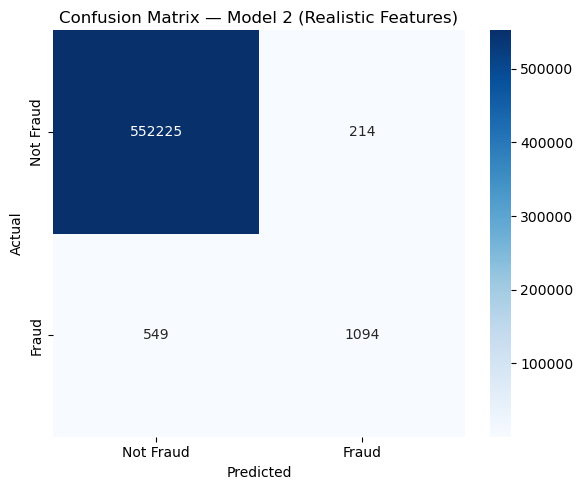

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test2, y_pred2)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Model 2 (Realistic Features)')
plt.tight_layout()
plt.savefig('confusion_matrix_model2.png', dpi=150)
plt.show()

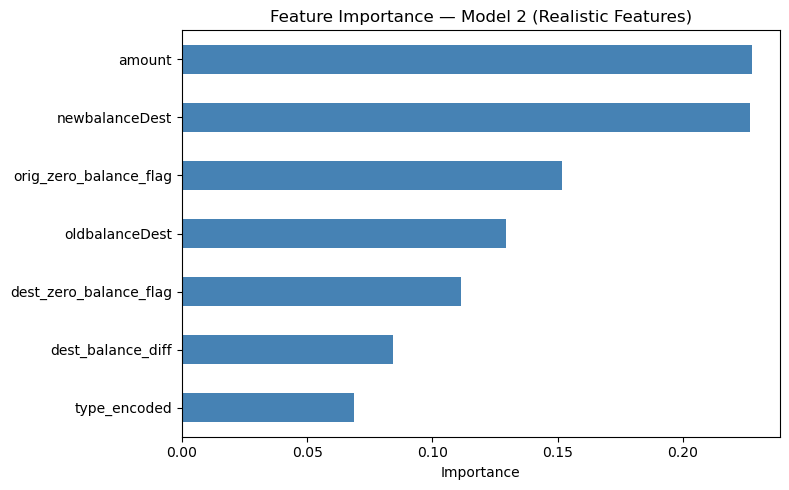

In [23]:
plt.figure(figsize=(8,5))
importances_v2.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance — Model 2 (Realistic Features)')
plt.tight_layout()
plt.savefig('feature_importance_model2.png', dpi=150)
plt.show()

In [24]:
import numpy as np
import pandas as pd

np.random.seed(42)
synthetic_rows = [] 
max_step = df['step'].max()  
print("Max step in data:", max_step)

Max step in data: 743


In [25]:
def create_circular_ring(ring_id, n_accounts, base_amount, start_step):
    """
    Creates a circular fraud ring: A -> B -> C -> ... -> A
    Money returns to the starting account.
    """
    accounts = [f"FRAUD_RING{ring_id}_{chr(65+i)}" for i in range(n_accounts)] 
    rows = []
    
    for i in range(n_accounts):
        sender = accounts[i]
        receiver = accounts[(i + 1) % n_accounts] 
        amount = base_amount + np.random.uniform(-150, 150)
        step = start_step + i  
        
        rows.append({
            'step': step,
            'type': 'TRANSFER',
            'amount': round(amount, 2),
            'nameOrig': sender,
            'oldbalanceOrg': amount + np.random.uniform(0, 1000), 
            'newbalanceOrig': 0.0, 
            'nameDest': receiver,
            'oldbalanceDest': 0.0,
            'newbalanceDest': amount,
            'isFraud': 0,         
            'isRingFraud': 1      
        })
    return rows

# Generate 10 circular rings, varying size (4-5 accounts) and amount
for ring_id in range(1, 11):
    n_accounts = np.random.choice([4, 5])
    base_amount = np.random.uniform(20000, 50000)
    start_step = np.random.randint(1, max_step - 10)
    synthetic_rows.extend(create_circular_ring(ring_id, n_accounts, base_amount, start_step))

print("Circular ring transactions created:", len(synthetic_rows))

Circular ring transactions created: 46


In [26]:
def create_mule_network(mule_id, n_victims, start_step):
    mule_account = f"MULE{mule_id}_ACC"
    final_dest = f"MULE{mule_id}_FINAL"
    rows = []
    
    total_collected = 0
    
    for v in range(n_victims):
        victim = f"MULE{mule_id}_VICTIM{v+1}"
        amount = np.random.uniform(5000, 40000)  
        step = start_step + np.random.randint(0, 3)  
        
        rows.append({
            'step': step,
            'type': 'TRANSFER',
            'amount': round(amount, 2),
            'nameOrig': victim,
            'oldbalanceOrg': amount + np.random.uniform(500, 5000),
            'newbalanceOrig': np.random.uniform(500, 5000),  
            'nameDest': mule_account,
            'oldbalanceDest': total_collected,
            'newbalanceDest': total_collected + amount,
            'isFraud': 0,
            'isRingFraud': 1
        })
        total_collected += amount
    
    forward_step = start_step + 3 
    forward_amount = round(total_collected * np.random.uniform(0.92, 0.99), 2)  
    
    rows.append({
        'step': forward_step,
        'type': 'CASH_OUT',
        'amount': forward_amount,
        'nameOrig': mule_account,
        'oldbalanceOrg': total_collected,
        'newbalanceOrig': round(total_collected - forward_amount, 2),
        'nameDest': final_dest,
        'oldbalanceDest': 0.0,
        'newbalanceDest': forward_amount,
        'isFraud': 0,
        'isRingFraud': 1
    })
    
    return rows

for mule_id in range(1, 15):
    n_victims = np.random.randint(5, 11)
    start_step = np.random.randint(1, max_step - 10)
    synthetic_rows.extend(create_mule_network(mule_id, n_victims, start_step))

print("Total transactions after mule networks:", len(synthetic_rows))

Total transactions after mule networks: 166


In [27]:
def create_layering_chain(chain_id, n_accounts, base_amount, start_step):

    accounts = [f"LAYER{chain_id}_{chr(65+i)}" for i in range(n_accounts)]
    rows = []
    
    current_amount = base_amount
    
    for i in range(n_accounts - 1):  
        sender = accounts[i]
        receiver = accounts[i + 1]
        step = start_step + i  
        
        next_amount = current_amount * np.random.uniform(0.95, 0.99)
        
        rows.append({
            'step': step,
            'type': 'TRANSFER',
            'amount': round(current_amount, 2),
            'nameOrig': sender,
            'oldbalanceOrg': round(current_amount + np.random.uniform(0, 500), 2),
            'newbalanceOrig': 0.0,  
            'nameDest': receiver,
            'oldbalanceDest': 0.0,
            'newbalanceDest': round(current_amount, 2),
            'isFraud': 0,
            'isRingFraud': 1
        })
        current_amount = next_amount
    
    return rows

# Generate 16 layering chains, 4-6 accounts each
for chain_id in range(1, 17):
    n_accounts = np.random.choice([4, 5, 6])
    base_amount = np.random.uniform(30000, 80000)
    start_step = np.random.randint(1, max_step - 10)
    synthetic_rows.extend(create_layering_chain(chain_id, n_accounts, base_amount, start_step))

print("Total synthetic transactions:", len(synthetic_rows))

Total synthetic transactions: 227


In [28]:
synthetic_df = pd.DataFrame(synthetic_rows)

df['isRingFraud'] = 0

df_combined = pd.concat([df, synthetic_df], ignore_index=True)

print("Original real transactions:", len(df))
print("Synthetic fraud ring transactions:", len(synthetic_df))
print("Combined total:", len(df_combined))
print("\nRing fraud label counts:")
print(df_combined['isRingFraud'].value_counts())

Original real transactions: 2770409
Synthetic fraud ring transactions: 227
Combined total: 2770636

Ring fraud label counts:
isRingFraud
0    2770409
1        227
Name: count, dtype: int64


In [29]:
import networkx as nx

G = nx.from_pandas_edgelist(
    df_combined,
    source='nameOrig',
    target='nameDest',
    edge_attr=['amount', 'step', 'type'], 
    create_using=nx.DiGraph()
)

print("Number of nodes (accounts):", G.number_of_nodes())
print("Number of edges (transactions):", G.number_of_edges())

Number of nodes (accounts): 3277766
Number of edges (transactions): 2770636


In [30]:
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

account_features = pd.DataFrame({
    'account': list(in_degree.keys()),
    'in_degree': list(in_degree.values()),
    'out_degree': list(out_degree.values())
})

print(account_features.describe())
print(account_features.sort_values('in_degree', ascending=False).head(10))

          in_degree    out_degree
count  3.277766e+06  3.277766e+06
mean   8.452818e-01  8.452818e-01
std    3.012543e+00  3.631361e-01
min    0.000000e+00  0.000000e+00
25%    0.000000e+00  1.000000e+00
50%    0.000000e+00  1.000000e+00
75%    0.000000e+00  1.000000e+00
max    7.500000e+01  3.000000e+00
          account  in_degree  out_degree
52    C1286084959         75           0
42     C665576141         68           0
136   C1360767589         68           0
63      C97730845         67           0
15     C248609774         64           0
2350  C2006081398         63           0
118   C2083562754         63           0
40    C1590550415         62           0
171   C1789550256         62           0
106   C1023714065         61           0


In [31]:
mule_accounts = account_features[account_features['account'].str.startswith('MULE') & account_features['account'].str.endswith('ACC')]
print(mule_accounts.sort_values('in_degree', ascending=False))

            account  in_degree  out_degree
3277556   MULE1_ACC         10           1
3277639  MULE10_ACC         10           1
3277627   MULE9_ACC         10           1
3277679  MULE14_ACC          9           1
3277661  MULE12_ACC          9           1
3277568   MULE2_ACC          8           1
3277651  MULE11_ACC          8           1
3277618   MULE8_ACC          7           1
3277609   MULE7_ACC          7           1
3277578   MULE3_ACC          6           1
3277586   MULE4_ACC          6           1
3277601   MULE6_ACC          6           1
3277594   MULE5_ACC          5           1
3277672  MULE13_ACC          5           1


In [32]:
account_features['fan_in_fan_out_ratio'] = account_features['in_degree'] / (account_features['out_degree'] + 1)
print(account_features.sort_values('fan_in_fan_out_ratio', ascending=False).head(15))

          account  in_degree  out_degree  fan_in_fan_out_ratio
52    C1286084959         75           0                  75.0
136   C1360767589         68           0                  68.0
42     C665576141         68           0                  68.0
63      C97730845         67           0                  67.0
15     C248609774         64           0                  64.0
2350  C2006081398         63           0                  63.0
118   C2083562754         63           0                  63.0
40    C1590550415         62           0                  62.0
171   C1789550256         62           0                  62.0
106   C1023714065         61           0                  61.0
74     C985934102         61           0                  61.0
309    C306206744         61           0                  61.0
1144  C1255024717         60           0                  60.0
27     C977993101         60           0                  60.0
1681   C991363637         59           0               

In [33]:
incoming_timing = df_combined.groupby('nameDest')['step'].agg(['min', 'max', 'count'])
incoming_timing['step_span'] = incoming_timing['max'] - incoming_timing['min']
incoming_timing = incoming_timing.rename(columns={'count': 'incoming_count'})

account_features = account_features.merge(
    incoming_timing[['step_span', 'incoming_count']],
    left_on='account', right_index=True, how='left'
)

print("Mule accounts:")
print(account_features[account_features['account'].str.startswith('MULE') & account_features['account'].str.endswith('ACC')][['account', 'in_degree', 'out_degree', 'step_span']])
    
print("\nTop real high in-degree accounts:")
print(account_features.sort_values('in_degree', ascending=False).head(10)[['account', 'in_degree', 'out_degree', 'step_span']])

Mule accounts:
            account  in_degree  out_degree  step_span
3277556   MULE1_ACC         10           1        2.0
3277568   MULE2_ACC          8           1        2.0
3277578   MULE3_ACC          6           1        2.0
3277586   MULE4_ACC          6           1        2.0
3277594   MULE5_ACC          5           1        2.0
3277601   MULE6_ACC          6           1        1.0
3277609   MULE7_ACC          7           1        1.0
3277618   MULE8_ACC          7           1        2.0
3277627   MULE9_ACC         10           1        2.0
3277639  MULE10_ACC         10           1        2.0
3277651  MULE11_ACC          8           1        1.0
3277661  MULE12_ACC          9           1        2.0
3277672  MULE13_ACC          5           1        2.0
3277679  MULE14_ACC          9           1        2.0

Top real high in-degree accounts:
          account  in_degree  out_degree  step_span
52    C1286084959         75           0      400.0
42     C665576141         68        

In [34]:
cycles = list(nx.simple_cycles(G, length_bound=6))

print("Total cycles found:", len(cycles))

Total cycles found: 10


In [35]:
for i, cycle in enumerate(cycles):
    print(f"Cycle {i+1}: {cycle}")

Cycle 1: ['FRAUD_RING10_C', 'FRAUD_RING10_D', 'FRAUD_RING10_E', 'FRAUD_RING10_A', 'FRAUD_RING10_B']
Cycle 2: ['FRAUD_RING9_D', 'FRAUD_RING9_A', 'FRAUD_RING9_B', 'FRAUD_RING9_C']
Cycle 3: ['FRAUD_RING8_B', 'FRAUD_RING8_C', 'FRAUD_RING8_D', 'FRAUD_RING8_A']
Cycle 4: ['FRAUD_RING7_A', 'FRAUD_RING7_B', 'FRAUD_RING7_C', 'FRAUD_RING7_D']
Cycle 5: ['FRAUD_RING6_A', 'FRAUD_RING6_B', 'FRAUD_RING6_C', 'FRAUD_RING6_D', 'FRAUD_RING6_E']
Cycle 6: ['FRAUD_RING5_B', 'FRAUD_RING5_C', 'FRAUD_RING5_D', 'FRAUD_RING5_E', 'FRAUD_RING5_A']
Cycle 7: ['FRAUD_RING4_C', 'FRAUD_RING4_D', 'FRAUD_RING4_E', 'FRAUD_RING4_A', 'FRAUD_RING4_B']
Cycle 8: ['FRAUD_RING3_D', 'FRAUD_RING3_E', 'FRAUD_RING3_A', 'FRAUD_RING3_B', 'FRAUD_RING3_C']
Cycle 9: ['FRAUD_RING2_C', 'FRAUD_RING2_D', 'FRAUD_RING2_E', 'FRAUD_RING2_A', 'FRAUD_RING2_B']
Cycle 10: ['FRAUD_RING1_C', 'FRAUD_RING1_D', 'FRAUD_RING1_A', 'FRAUD_RING1_B']


In [36]:
accounts_in_cycles = set()
for cycle in cycles:
    for account in cycle:
        accounts_in_cycles.add(account)
print("Total unique accounts involved in cycles:", len(accounts_in_cycles))

account_features['is_in_cycle'] = account_features['account'].isin(accounts_in_cycles).astype(int)
print(account_features[account_features['is_in_cycle'] == 1])

Total unique accounts involved in cycles: 46
                account  in_degree  out_degree  fan_in_fan_out_ratio  \
3277509   FRAUD_RING1_A          1           1                   0.5   
3277510   FRAUD_RING1_B          1           1                   0.5   
3277511   FRAUD_RING1_C          1           1                   0.5   
3277512   FRAUD_RING1_D          1           1                   0.5   
3277513   FRAUD_RING2_A          1           1                   0.5   
3277514   FRAUD_RING2_B          1           1                   0.5   
3277515   FRAUD_RING2_C          1           1                   0.5   
3277516   FRAUD_RING2_D          1           1                   0.5   
3277517   FRAUD_RING2_E          1           1                   0.5   
3277518   FRAUD_RING3_A          1           1                   0.5   
3277519   FRAUD_RING3_B          1           1                   0.5   
3277520   FRAUD_RING3_C          1           1                   0.5   
3277521   FRAUD_RIN

In [37]:
incoming_step = df_combined.groupby('nameDest')['step'].min().rename('incoming_step')
outgoing_step = df_combined.groupby('nameOrig')['step'].min().rename('outgoing_step')

timing_check = pd.concat([incoming_step, outgoing_step], axis=1)
timing_check['pass_through_gap'] = timing_check['outgoing_step'] - timing_check['incoming_step']

account_features = account_features.merge(
    timing_check[['pass_through_gap']],
    left_on='account', right_index=True, how='left'
)

layer_accounts = account_features[account_features['account'].str.startswith('LAYER')]
print(layer_accounts[['account', 'in_degree', 'out_degree', 'pass_through_gap']].head(20))

          account  in_degree  out_degree  pass_through_gap
3277689  LAYER1_A          0           1               NaN
3277690  LAYER1_B          1           1               1.0
3277691  LAYER1_C          1           1               1.0
3277692  LAYER1_D          1           0               NaN
3277693  LAYER2_A          0           1               NaN
3277694  LAYER2_B          1           1               1.0
3277695  LAYER2_C          1           1               1.0
3277696  LAYER2_D          1           1               1.0
3277697  LAYER2_E          1           0               NaN
3277698  LAYER3_A          0           1               NaN
3277699  LAYER3_B          1           1               1.0
3277700  LAYER3_C          1           1               1.0
3277701  LAYER3_D          1           1               1.0
3277702  LAYER3_E          1           1               1.0
3277703  LAYER3_F          1           0               NaN
3277704  LAYER4_A          0           1               N

In [38]:
account_features['is_fast_pass_through'] = (
    (account_features['pass_through_gap'] >= 0) &
    (account_features['pass_through_gap'] <= 2)
).astype(int)

print("Total accounts flagged as fast pass-through:", account_features['is_fast_pass_through'].sum())

Total accounts flagged as fast pass-through: 89


In [39]:
our_layer_accounts = account_features[account_features['account'].str.startswith('LAYER')]
print("Our layering accounts flagged as fast pass-through:", our_layer_accounts['is_fast_pass_through'].sum())
print("Total layering accounts that exist:", len(our_layer_accounts))

real_flagged = account_features[
    (account_features['is_fast_pass_through'] == 1) &
    (account_features['account'].str.startswith('C'))
]
print("\nReal accounts flagged as fast pass-through:", len(real_flagged))

Our layering accounts flagged as fast pass-through: 45
Total layering accounts that exist: 77

Real accounts flagged as fast pass-through: 8


In [40]:
account_features['is_mule_pattern'] = (
    (account_features['in_degree'] >= 5) &
    (account_features['out_degree'] <= 1) &
    (account_features['step_span'] <= 3)
).astype(int)

print("Accounts flagged as mule pattern:", account_features['is_mule_pattern'].sum())

Accounts flagged as mule pattern: 21


In [41]:
account_features['risk_score'] = (
    account_features['is_in_cycle'] * 40 +          
    account_features['is_mule_pattern'] * 30 +       
    account_features['is_fast_pass_through'] * 20    
)

print(account_features.sort_values('risk_score', ascending=False).head(20)[
    ['account', 'is_in_cycle', 'is_mule_pattern', 'is_fast_pass_through', 'risk_score']
])

                account  is_in_cycle  is_mule_pattern  is_fast_pass_through  \
3277522   FRAUD_RING3_E            1                0                     1   
3277529   FRAUD_RING5_B            1                0                     1   
3277543   FRAUD_RING8_B            1                0                     1   
3277544   FRAUD_RING8_C            1                0                     1   
3277545   FRAUD_RING8_D            1                0                     1   
3277530   FRAUD_RING5_C            1                0                     1   
3277547   FRAUD_RING9_B            1                0                     1   
3277531   FRAUD_RING5_D            1                0                     1   
3277548   FRAUD_RING9_C            1                0                     1   
3277532   FRAUD_RING5_E            1                0                     1   
3277534   FRAUD_RING6_B            1                0                     1   
3277535   FRAUD_RING6_C            1                

In [42]:
def generate_reason(row):
    reasons = []
    if row['is_in_cycle'] == 1:
        reasons.append("Part of a circular money transfer (funds returned to origin)")
    if row['is_mule_pattern'] == 1:
        reasons.append(f"Mule-like pattern: received from {row['in_degree']} accounts within {row['step_span']} hours, forwarded quickly")
    if row['is_fast_pass_through'] == 1:
        reasons.append("Fast pass-through: received and forwarded money within 1-2 hours")
    return "; ".join(reasons) if reasons else "No red flags"

account_features['risk_reason'] = account_features.apply(generate_reason, axis=1)

print(account_features.sort_values('risk_score', ascending=False).head(15)[['account', 'risk_score', 'risk_reason']].to_string(index=False))

      account  risk_score                                                                                                                    risk_reason
FRAUD_RING3_E          60 Part of a circular money transfer (funds returned to origin); Fast pass-through: received and forwarded money within 1-2 hours
FRAUD_RING5_B          60 Part of a circular money transfer (funds returned to origin); Fast pass-through: received and forwarded money within 1-2 hours
FRAUD_RING8_B          60 Part of a circular money transfer (funds returned to origin); Fast pass-through: received and forwarded money within 1-2 hours
FRAUD_RING8_C          60 Part of a circular money transfer (funds returned to origin); Fast pass-through: received and forwarded money within 1-2 hours
FRAUD_RING8_D          60 Part of a circular money transfer (funds returned to origin); Fast pass-through: received and forwarded money within 1-2 hours
FRAUD_RING5_C          60 Part of a circular money transfer (funds returned to ori

In [43]:
real_accounts = account_features[account_features['account'].str.startswith('C')]
print("Real account risk score distribution:")
print(real_accounts['risk_score'].value_counts())

print("\nReal accounts with risk_score > 0:")
print(real_accounts[real_accounts['risk_score'] > 0][['account', 'risk_score', 'risk_reason']])

Real account risk score distribution:
risk_score
0     3277494
20          8
30          7
Name: count, dtype: int64

Real accounts with risk_score > 0:
             account  risk_score  \
9471      C541307861          30   
334552    C628560339          20   
474162    C487001248          20   
729678   C1883483535          20   
824541   C1277761376          20   
833963    C809007991          20   
1350964   C553116678          20   
2143786   C923763422          30   
2149823  C1605399023          30   
2152155  C2081696688          30   
2160205  C1723556849          30   
2163385   C806096366          30   
2179823    C53048224          30   
2403935  C1959400230          20   
2690985    C46278438          20   

                                               risk_reason  
9471     Mule-like pattern: received from 6 accounts wi...  
334552   Fast pass-through: received and forwarded mone...  
474162   Fast pass-through: received and forwarded mone...  
729678   Fast pass-through

In [44]:
suspicious_accounts = account_features[account_features['risk_score'] > 0]['account'].tolist()
print("Total suspicious accounts to visualize:", len(suspicious_accounts))

G_sub = G.subgraph(suspicious_accounts)

print("Subgraph nodes:", G_sub.number_of_nodes())
print("Subgraph edges:", G_sub.number_of_edges())

Total suspicious accounts to visualize: 120
Subgraph nodes: 120
Subgraph edges: 75


C:\Users\Administrator\AppData\Local\Temp\ipykernel_6396\862746975.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6396\862746975.py:29: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('fraud_network_graph.png', dpi=150)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6396\862746975.py:29: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('fraud_network_graph.png', dpi=150)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6396\862746975.py:29: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('fraud_network_graph.png', dpi=150)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.ca

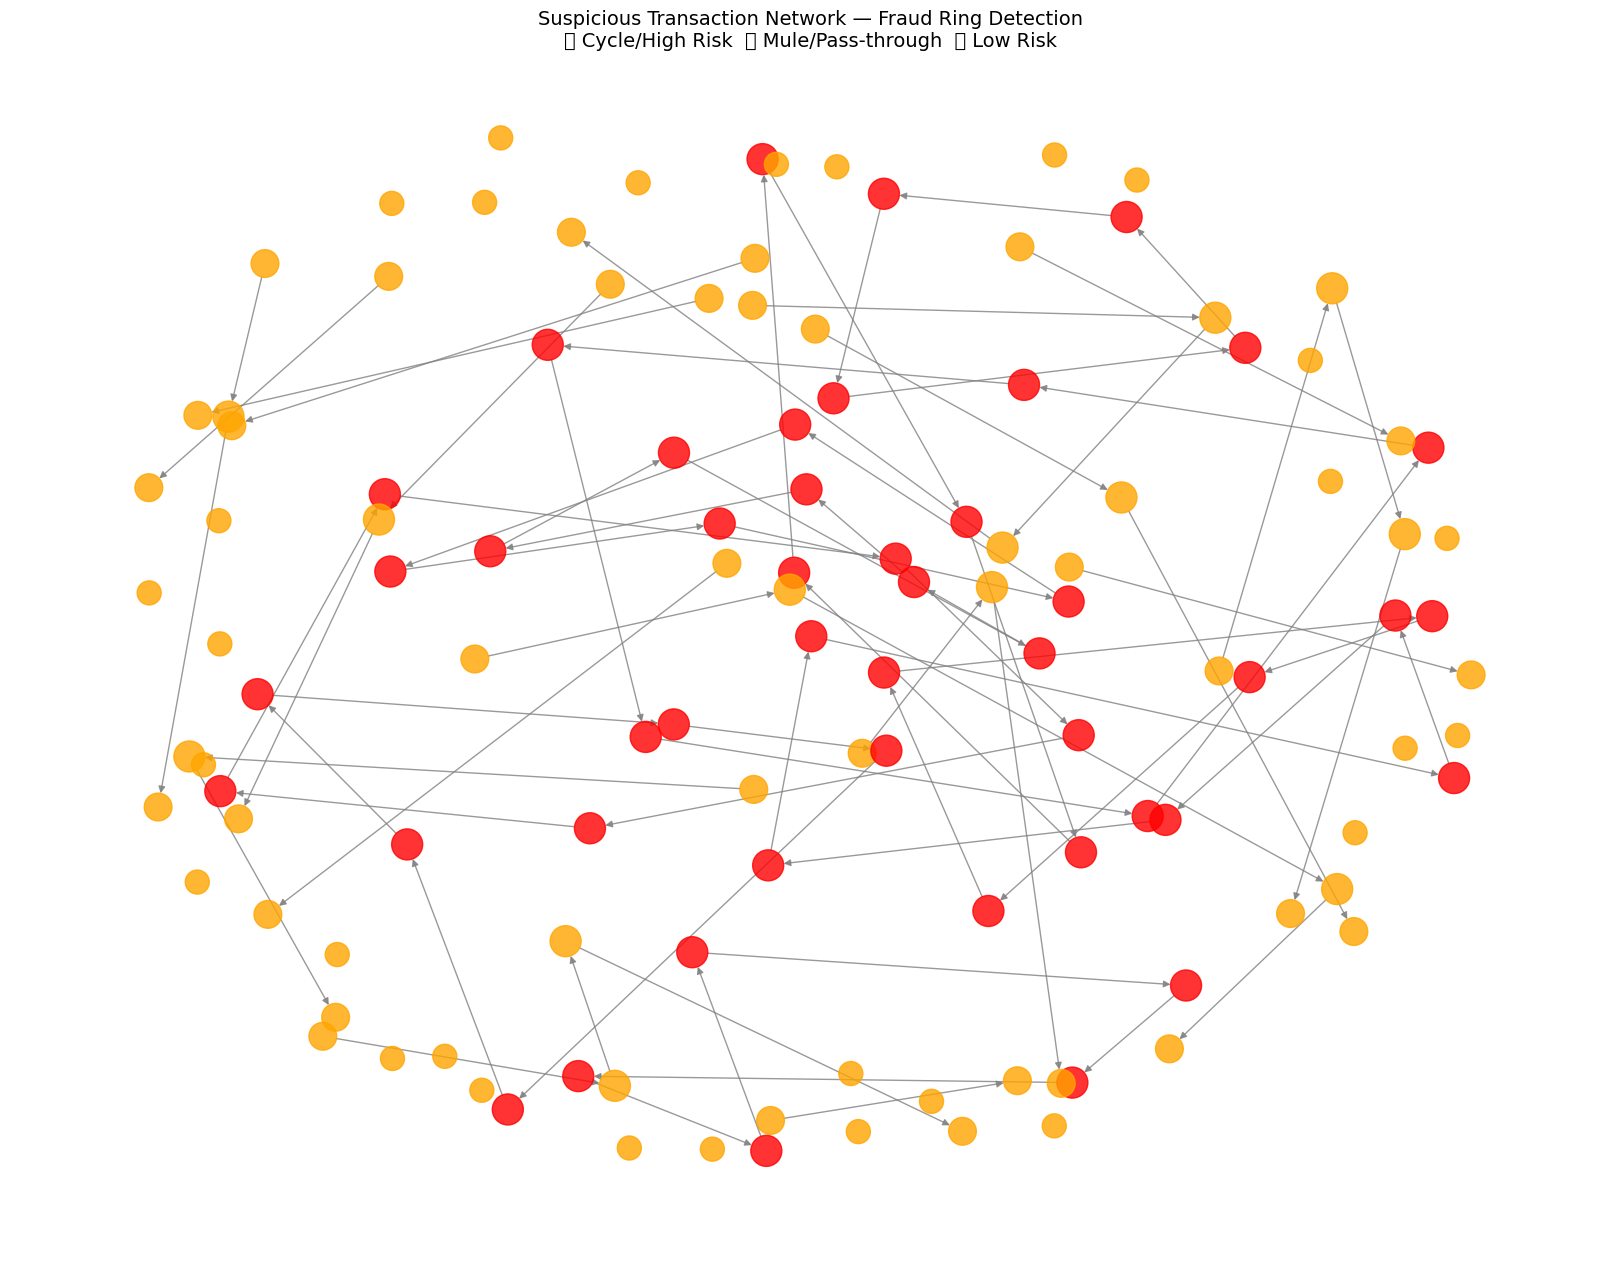

In [45]:
import matplotlib.pyplot as plt

node_risk = account_features.set_index('account')['risk_score'].to_dict()
def get_color(node):
    score = node_risk.get(node, 0)
    if score >= 40:
        return 'red'      # high risk - cycles
    elif score >= 20:
        return 'orange'   # medium risk - mule/pass-through
    else:
        return 'green'    # low/no risk

node_colors = [get_color(node) for node in G_sub.nodes()]
node_sizes = [300 + (G_sub.degree(node) * 100) for node in G_sub.nodes()]
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G_sub, k=0.5, seed=42)  
nx.draw(
    G_sub, pos,
    node_color=node_colors,
    node_size=node_sizes,
    with_labels=False,      
    edge_color='gray',
    arrows=True,
    arrowsize=10,
    alpha=0.8
)
plt.title("Suspicious Transaction Network — Fraud Ring Detection\n🔴 Cycle/High Risk  🟠 Mule/Pass-through  🟢 Low Risk", fontsize=14)
plt.tight_layout()
plt.savefig('fraud_network_graph.png', dpi=150)
plt.show()

Expanded subgraph nodes: 387
Expanded subgraph edges: 342
Number of separate clusters found: 55


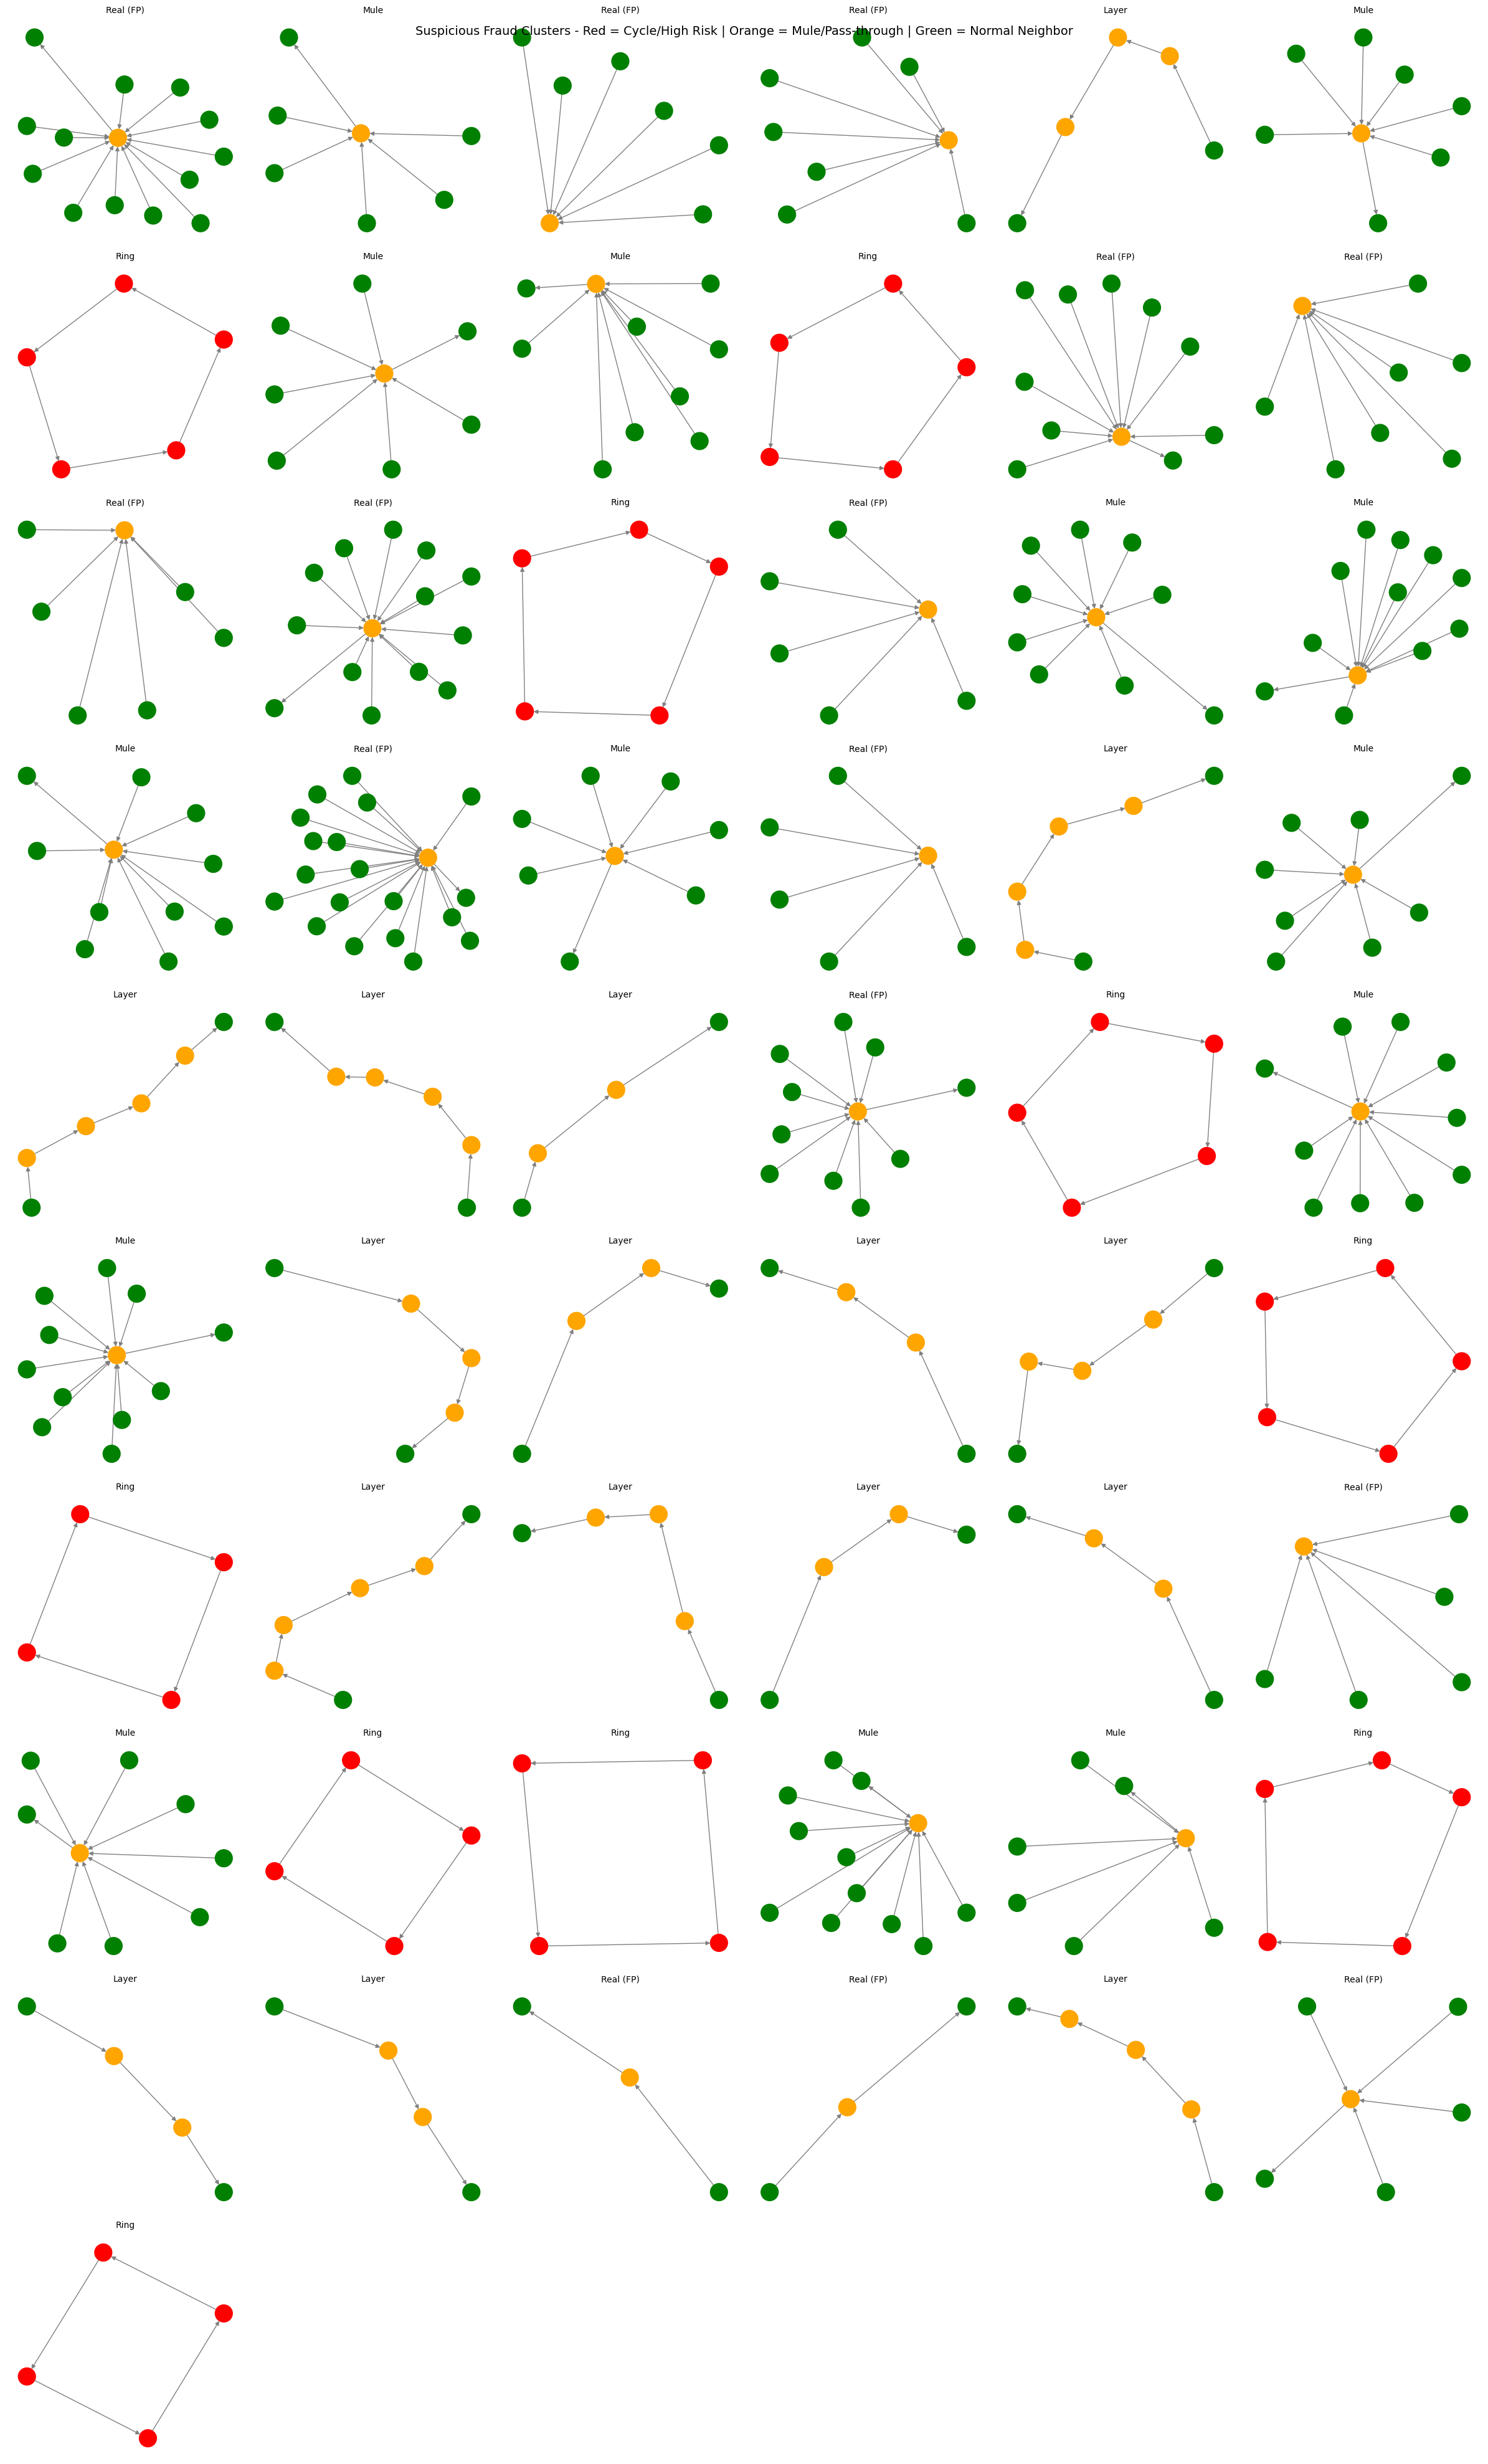

In [46]:
import matplotlib.pyplot as plt
import networkx as nx
import math

expanded_accounts = set(suspicious_accounts)
for acc in suspicious_accounts:
    if acc in G:
        expanded_accounts.update(G.predecessors(acc)) 
        expanded_accounts.update(G.successors(acc))   
G_sub2 = G.subgraph(expanded_accounts)
print("Expanded subgraph nodes:", G_sub2.number_of_nodes())
print("Expanded subgraph edges:", G_sub2.number_of_edges())

components = list(nx.weakly_connected_components(G_sub2))
print("Number of separate clusters found:", len(components))

n_components = len(components)
cols = 6
rows = math.ceil(n_components / cols)
fig, axes = plt.subplots(rows, cols, figsize=(24, 4 * rows))
axes = axes.flatten()

for i, component in enumerate(components):
    subG = G_sub2.subgraph(component)
    ax = axes[i]
    
    colors = [get_color(node) for node in subG.nodes()]
    pos = nx.spring_layout(subG, seed=42)
    
    nx.draw(subG, pos, ax=ax, node_color=colors, node_size=400,
             with_labels=False, edge_color='gray', arrows=True, arrowsize=10)
    
    names = list(component)
    if any("FRAUD_RING" in n for n in names):
        cluster_type = "Ring"
    elif any("MULE" in n for n in names):
        cluster_type = "Mule"
    elif any("LAYER" in n for n in names):
        cluster_type = "Layer"
    else:
        cluster_type = "Real (FP)"
    ax.set_title(cluster_type, fontsize=10)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Suspicious Fraud Clusters - Red = Cycle/High Risk | Orange = Mule/Pass-through | Green = Normal Neighbor", fontsize=14)
plt.tight_layout()
plt.savefig('fraud_clusters_grid_v2.png', dpi=150)
plt.show()

In [47]:
account_features.to_csv('account_risk_data.csv', index=False)

transaction_summary = df_combined.groupby(['type', 'isFraud']).agg(
    total_transactions=('amount', 'count'),
    total_amount=('amount', 'sum'),
    avg_amount=('amount', 'mean')
).reset_index()
transaction_summary.to_csv('transaction_summary.csv', index=False)

suspicious_export = account_features[account_features['risk_score'] > 0][
    ['account', 'risk_score', 'is_in_cycle', 'is_mule_pattern', 'is_fast_pass_through', 'risk_reason']
]
suspicious_export.to_csv('suspicious_accounts.csv', index=False)

print("Files exported:")
print("account_risk_data.csv:", account_features.shape)
print("transaction_summary.csv:", transaction_summary.shape)
print("suspicious_accounts.csv:", suspicious_export.shape)

Files exported:
account_risk_data.csv: (3277766, 12)
transaction_summary.csv: (4, 5)
suspicious_accounts.csv: (120, 6)
